# Manual DTW Barycenter Averaging
This notebook keeps the barycenter averaging and clustering logic explicit and step-by-step. The only external DTW primitives come from `aeon`, which we use for the DTW distance and alignment path.

In [6]:
import subprocess
import sys


def ensure_package(package_name):
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


ensure_package("aeon")

import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

from aeon.distances import dtw_alignment_path, dtw_distance

## DTW Alignment Example
Start with two short univariate series and inspect the DTW path returned by `aeon`.

In [7]:
x = np.array([0.5, 1.0, 2.0, -1.0, -1.5, -1.0, -0.2, 1.5, 2.0, 2.5])
y = np.array([0.0, -0.5, -1.0, 0.0, 0.5, 0.5, 0.0, 0.0, 0.5, 3.0])

alignment_path, dtw_cost = dtw_alignment_path(x, y)
print(f"DTW distance: {dtw_cost:.3f}")
print(f"Alignment steps: {len(alignment_path)}")

DTW distance: 9.100
Alignment steps: 14


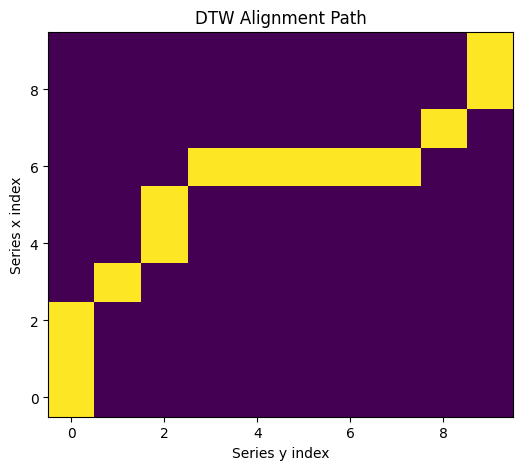

In [8]:
def plot_dtw_alignment(x, y, alignment_path, title="DTW Alignment Path"):
    alignment_matrix = np.zeros((len(x), len(y)))
    for i, j in alignment_path:
        alignment_matrix[i, j] = 1

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(alignment_matrix, cmap="viridis", origin="lower", aspect="auto")
    ax.set_xlabel("Series y index")
    ax.set_ylabel("Series x index")
    ax.set_title(title)
    plt.show()


plot_dtw_alignment(x, y, alignment_path)

## Manual DTW Barycenter Average
The averaging loop is implemented from scratch. Each update aligns every series to the current center using `aeon`'s DTW path, then averages the aligned values position by position.

In [9]:
def dtw_barycenter_average(X, max_iters=30, tol=1e-5, verbose=False):
    center = dtw_medoid(X)
    prev_cost = np.inf

    for iteration in range(max_iters):
        center, cost = dtw_ba_update(center, X, verbose=verbose)
        if verbose:
            print(f"Iteration {iteration + 1}: average DTW cost = {cost:.4f}")

        if abs(prev_cost - cost) < tol:
            if verbose:
                print(f"Converged after {iteration + 1} iterations")
            break

        prev_cost = cost

    return center


def dtw_ba_update(center, X, verbose=False):
    sums = np.zeros_like(center, dtype=float)
    counts = np.zeros_like(center, dtype=float)
    total_cost = 0.0

    for series in X:
        alignment_path, dist = dtw_alignment_path(series, center)
        for i, j in alignment_path:
            sums[j] += series[i]
            counts[j] += 1
        total_cost += dist

    new_center = np.divide(sums, counts, out=center.astype(float).copy(), where=counts > 0)
    avg_cost = total_cost / len(X)

    if verbose:
        print(f"Average cost: {avg_cost:.4f}")

    return new_center, avg_cost


def dtw_medoid(X):
    n = X.shape[0]
    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            dist_matrix[i, j] = dtw_distance(X[i], X[j])

    medoid_index = np.argmin(np.sum(dist_matrix, axis=1))
    return X[medoid_index].astype(float)

### What `dtw_ba_update` Does
`dtw_ba_update` performs **one** barycenter update step for a fixed current center.

The function works in three stages:

1. For each time series in `X`, compute a DTW alignment path against the current `center`.
2. Use that path to accumulate values into the center positions:
   - `sums[j]` stores the total of all series values aligned to center index `j`
   - `counts[j]` stores how many values were aligned to center index `j`
3. Compute the updated center with `new_center[j] = sums[j] / counts[j]`.

So the key idea is: DTW tells us **which sample values should vote for each center position**, and then the update simply averages those votes.

`avg_cost` is the mean DTW distance from the current center to all series in `X`, which lets us monitor convergence across iterations.

Average cost: 1.5000
Iteration 1: average DTW cost = 1.5000
Average cost: 1.2778
Iteration 2: average DTW cost = 1.2778
Average cost: 1.2778
Iteration 3: average DTW cost = 1.2778
Converged after 3 iterations
Pairwise DTW distance between the first two series: 7.0
Toy DTW barycenter: [0.83333333 4.         3.66666667 8.5        7.5       ]


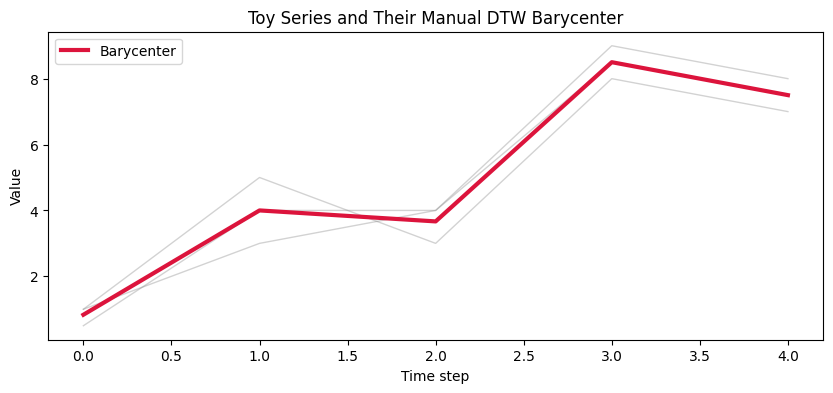

In [12]:
toy_series = np.array([
    [1.0, 3.0, 4.0, 9.0, 8.0],
    [1.0, 5.0, 3.0, 8.0, 7.0],
    [0.5, 4.0, 4.0, 8.5, 7.5],
])

def plot_cluster_with_barycenter(series, barycenter, title):
    plt.figure(figsize=(10, 4))
    for ts in series:
        plt.plot(ts, color="gray", alpha=0.35, linewidth=1)
    plt.plot(barycenter, color="crimson", linewidth=3, label="Barycenter")
    plt.title(title)
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.legend()
    plt.show()


toy_barycenter = dtw_barycenter_average(toy_series, verbose=True)
print("Pairwise DTW distance between the first two series:", dtw_distance(toy_series[0], toy_series[1]))
print("Toy DTW barycenter:", toy_barycenter)
plot_cluster_with_barycenter(toy_series, toy_barycenter, "Toy Series and Their Manual DTW Barycenter")

## Synthetic Dataset
Create an equal-length univariate dataset. For the manual implementation we keep the data in the simple `(n_samples, n_timesteps)` layout.

In [13]:
n_samples = 100
n_clusters = 3
n_timesteps = 50

X, true_labels = make_blobs(
    n_samples=n_samples,
    centers=n_clusters,
    n_features=n_timesteps,
    cluster_std=1.0,
    random_state=42,
)

print("Dataset shape:", X.shape)

Dataset shape: (100, 50)


## Manual DTW Barycenter of One Cluster
Before clustering, compute the barycenter for one known cluster to isolate the averaging step.

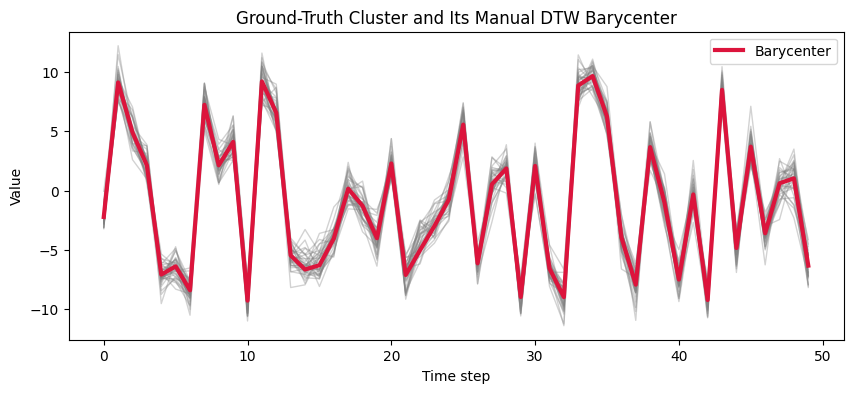

In [14]:
cluster_zero = X[true_labels == 0]
cluster_zero_barycenter = dtw_barycenter_average(cluster_zero)

plot_cluster_with_barycenter(
    cluster_zero,
    cluster_zero_barycenter,
    "Ground-Truth Cluster and Its Manual DTW Barycenter",
)

## Manual K-means with DTW Barycenter Updates
Keep the clustering loop explicit: assign each series to the nearest centroid with DTW, then recompute each centroid with the manual barycenter update.

In [15]:
def k_means_clustering(data, k, max_iters=20, tol=1e-5, random_state=42, verbose=False):
    rng = np.random.default_rng(random_state)
    centroids = data[rng.choice(data.shape[0], size=k, replace=False)].astype(float).copy()
    prev_inertia = np.inf

    for iteration in range(max_iters):
        distance_matrix = np.array([
            [dtw_distance(series, centroid) for centroid in centroids]
            for series in data
        ])
        labels = np.argmin(distance_matrix, axis=1)
        inertia = np.sum(np.min(distance_matrix, axis=1))

        new_centroids = centroids.copy()
        for cluster_id in range(k):
            cluster_data = data[labels == cluster_id]
            if len(cluster_data) == 0:
                continue
            new_centroids[cluster_id] = dtw_barycenter_average(cluster_data, tol=tol)

        if verbose:
            print(f"Iteration {iteration + 1}: total DTW inertia = {inertia:.4f}")

        if abs(prev_inertia - inertia) < tol:
            break

        centroids = new_centroids
        prev_inertia = inertia

    return labels, centroids, inertia

In [16]:
labels, centroids, inertia = k_means_clustering(
    X,
    n_clusters,
    max_iters=10,
    random_state=42,
    verbose=True,
)

ari = adjusted_rand_score(true_labels, labels)
print(f"Adjusted Rand Index: {ari:.2f}")
print(f"Final total DTW inertia: {inertia:.2f}")

Iteration 1: total DTW inertia = 51661.7307
Iteration 2: total DTW inertia = 20630.2436
Iteration 3: total DTW inertia = 4809.4701
Iteration 4: total DTW inertia = 4809.4701
Adjusted Rand Index: 1.00
Final total DTW inertia: 4809.47


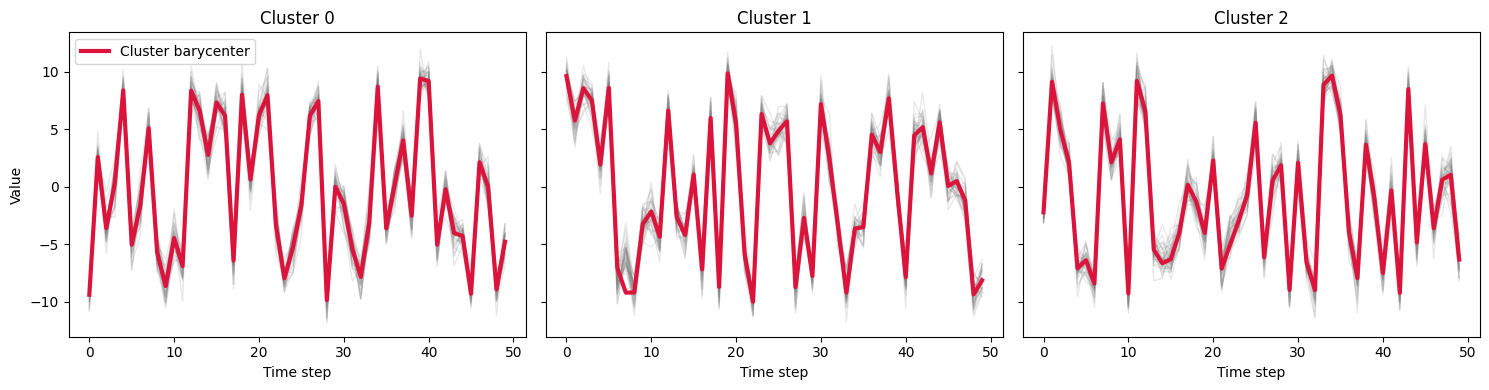

In [17]:
fig, axs = plt.subplots(1, n_clusters, figsize=(15, 4), sharey=True)

for i in range(n_clusters):
    cluster_series = X[labels == i]
    for ts in cluster_series:
        axs[i].plot(ts, color="gray", alpha=0.18, linewidth=1)
    axs[i].plot(centroids[i], color="crimson", linewidth=3, label="Cluster barycenter")
    axs[i].set_title(f"Cluster {i}")
    axs[i].set_xlabel("Time step")

axs[0].set_ylabel("Value")
axs[0].legend()
plt.tight_layout()
plt.show()